<a href="https://colab.research.google.com/github/aryanmotghare293/AI-Resume-Screening/blob/main/Indian_Liver_Patient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#WalMart sales analysis

In [42]:
import pandas as pd
import numpy as np
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [9]:
ilp=pd.read_csv("Indian_Liver_Patient.csv")

In [10]:
ilp.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [21]:
ilp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               579 non-null    int64  
 1   gender            579 non-null    object 
 2   tot_bilirubin     579 non-null    float64
 3   direct_bilirubin  579 non-null    float64
 4   tot_proteins      579 non-null    int64  
 5   albumin           579 non-null    int64  
 6   ag_ratio          579 non-null    int64  
 7   sgpt              579 non-null    float64
 8   sgot              579 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        579 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 54.3+ KB


In [14]:
ilp.isnull().sum()

,0
age,0
gender,0
tot_bilirubin,0
direct_bilirubin,0
tot_proteins,0
albumin,0
ag_ratio,0
sgpt,0
sgot,0
alkphos,4


In [15]:
ilp=ilp.dropna()
print("The data set rows after droping the null values :",len(ilp))

The data set rows after droping the null values : 579


In [16]:
ilp.info()


<class 'pandas.core.frame.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               579 non-null    int64  
 1   gender            579 non-null    object 
 2   tot_bilirubin     579 non-null    float64
 3   direct_bilirubin  579 non-null    float64
 4   tot_proteins      579 non-null    int64  
 5   albumin           579 non-null    int64  
 6   ag_ratio          579 non-null    int64  
 7   sgpt              579 non-null    float64
 8   sgot              579 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        579 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 54.3+ KB


In [17]:
ilp.describe()

,age,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,44.782383,3.315371,1.494128,291.366149,81.126079,110.414508,6.481693,3.138515,0.947064,1.284974
std,16.221786,6.227716,2.816499,243.561863,183.182845,289.850034,1.084641,0.794435,0.319592,0.451792
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,61.000000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [20]:
ilp.shape

(579, 11)

In [22]:
print(ilp.duplicated().sum())
ilp.drop_duplicates(inplace=True)

13


In [24]:
#Featuee Engineering

le=LabelEncoder()

ilp['gender']=le.fit_transform(ilp['gender'])
ilp.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [31]:
#Data Aggregation
print("+"*50)
print("Data Aggregation")
print("+"*50)
numeric_cols = ilp.select_dtypes(include=np.number)
print("Mean:",np.mean(numeric_cols))
print("Max_value",np.max(numeric_cols))
print("Min_value",np.min(numeric_cols))
print("Median_value",np.median(numeric_cols))
print("Satandered Values \n",np.std(numeric_cols))

++++++++++++++++++++++++++++++++++++++++++++++++++
Data Aggregation
++++++++++++++++++++++++++++++++++++++++++++++++++
Mean: 49.54226951493736
Max_value 4929.0
Min_value 0.0
Median_value 3.9
Satandered Values 
 age                  16.260510
gender                0.429383
tot_bilirubin         6.281172
direct_bilirubin      2.838974
tot_proteins        245.719205
albumin             181.883993
ag_ratio            291.583972
sgpt                  1.086551
sgot                  0.795042
alkphos               0.319353
is_patient            0.451993
dtype: float64


In [32]:
#featuree Scalling

X=ilp.drop("is_patient",axis=1)
y=ilp["is_patient"]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

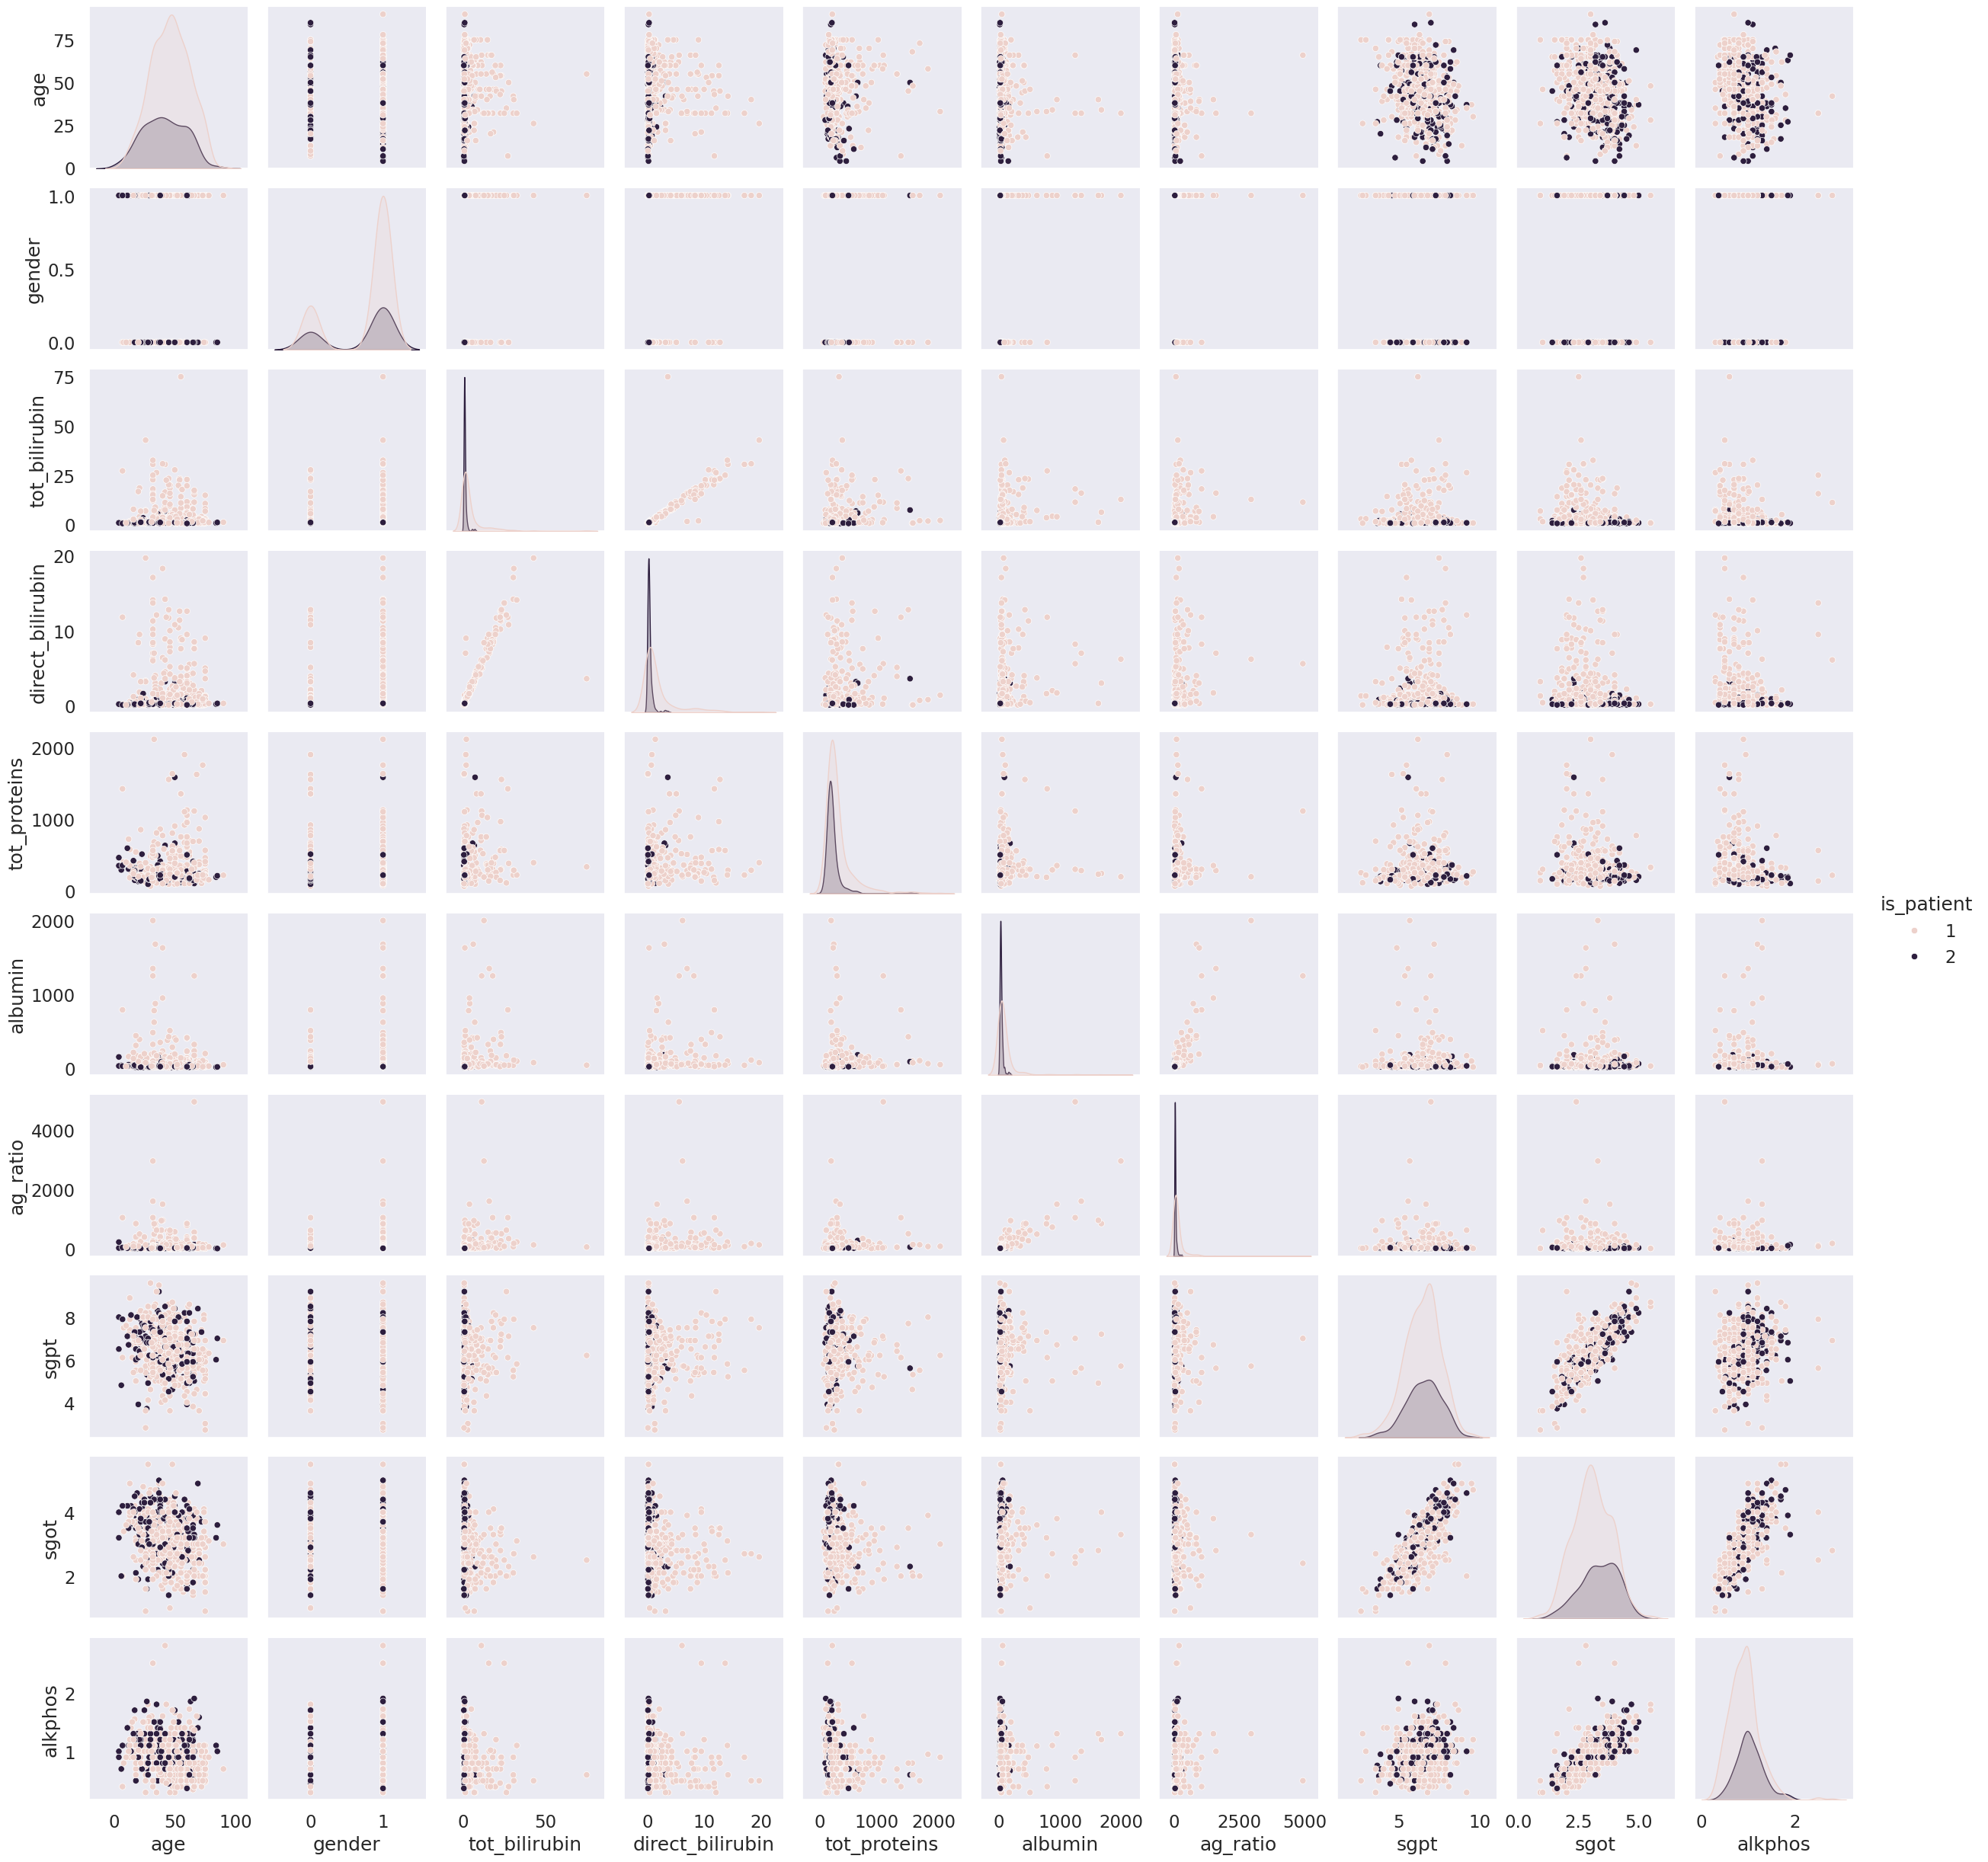

In [36]:
#data vizualiztion

sns.set_style("dark")
sns.set_context("notebook",font_scale=1.5,rc={"lines.linewidth":2.5})

#feature to vizualize
To_plot = [
    "is_patient",
    "gender",
    "total_bilirubin",
    "direct_bilirubin",
    "alkaline_phosphotase",
    "alamine_aminotransferase",
    "aspartate_aminotransferase"]
sns.pairplot(ilp,hue="is_patient")

In [37]:
#Machine learning model

In [38]:
#Kmean Clustering
#finding optimal k

wcss=[]

for i in range (1,11):
  kmean = KMeans(n_clusters=i,init="k-means++",random_state=42)
  kmean.fit(X_scaled)
  wcss.append(kmean.inertia_)

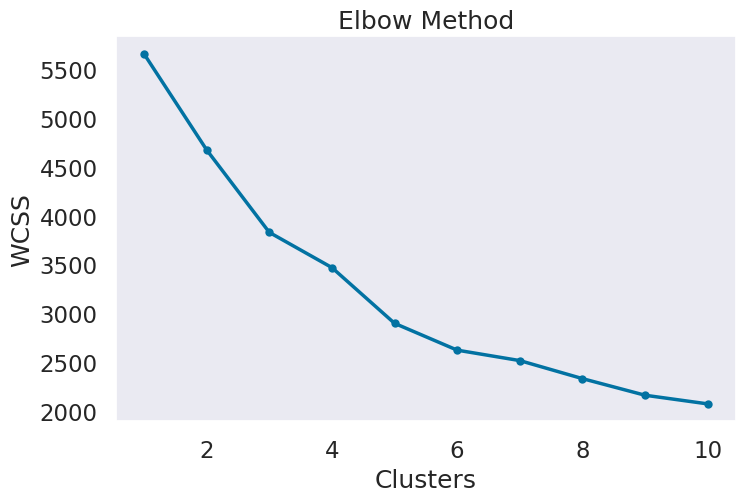

In [39]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=2,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

ilp['Cluster'] = clusters

print(ilp[['Cluster']].head())

   Cluster
0        1
1        0
2        1
3        1
4        1


In [43]:
#random forest

X_train,X_test,Y_train,Y_test= train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [46]:
y_pred = rf.predict(X_test)

In [47]:
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6228070175438597


In [48]:
f1=f1_score(Y_test,y_pred)
print("F1 score:",f1)

F1 score: 0.7455621301775148


In [49]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           1       0.65      0.88      0.75        72
           2       0.47      0.19      0.27        42

    accuracy                           0.62       114
   macro avg       0.56      0.53      0.51       114
weighted avg       0.58      0.62      0.57       114



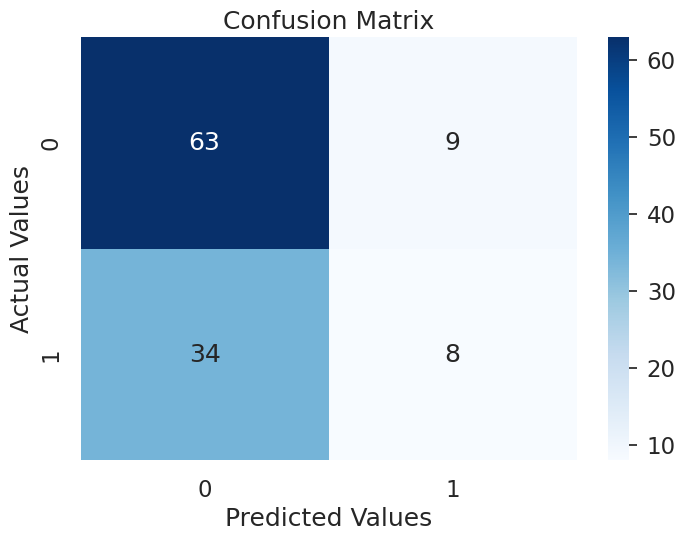

In [50]:
#Confusion MAtrix

cm= confusion_matrix(Y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

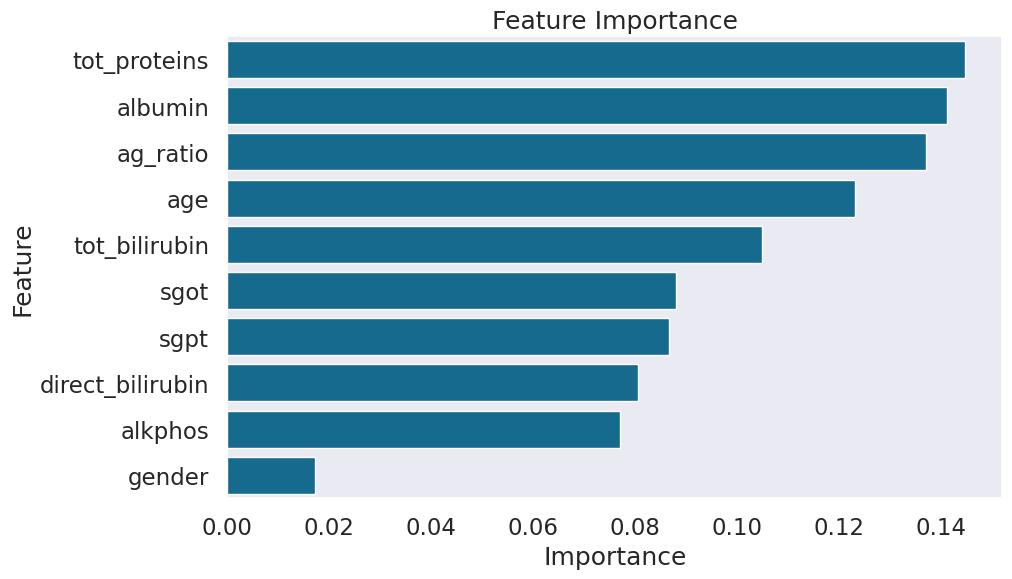

In [51]:
#featuee Importtance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()


In [52]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [55]:
import joblib

joblib.dump(rf, "models/random_forest.pkl")

['models/random_forest.pkl']

In [56]:
!ls models

random_forest.pkl


In [57]:
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")

['models/label_encoder.pkl']

In [58]:
from google.colab import files

files.download("models/random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
pip freeze > requirements.txt

In [60]:
plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 800x550 with 0 Axes>

In [63]:
!git config --global user.email "aryanmotghare293@gmail.com"
!git config --global user.name "aryanmotghare293"

In [64]:
!git clone https://github.com/aryanmotghare293/Indian-Liver-Disease-Prediction.git

Cloning into 'Indian-Liver-Disease-Prediction'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [67]:
!cp Indian_Liver_Patient.ipynb Indian-Liver-Disease-Prediction/notebooks/

cp: cannot stat 'Indian_Liver_Patient.ipynb': No such file or directory


In [69]:
%cd Indian-Liver-Disease-Prediction/

!git add .

!git commit -m "Initial ML project upload"

!git push origin main

/content/Indian-Liver-Disease-Prediction
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
